In [1]:
import sklearn
import imblearn
import numpy as np
import keras_tuner
import tensorflow as tf
from collections import Counter
import matplotlib.pyplot as plt
import Modules.constants as constants
import Modules.ds_loader as ds_loader

SAMPLE_PERCENTAGE = 1.0

DATA_PATH = constants.DATASET
TRAIN_DIR = DATA_PATH / "train"
VAL_DIR = DATA_PATH / "val"
TEST_DIR = DATA_PATH / "test"

X_train, y_train = ds_loader.load_all_data(TRAIN_DIR, SAMPLE_PERCENTAGE)
X_val, y_val = ds_loader.load_all_data(VAL_DIR, SAMPLE_PERCENTAGE)
X_test, y_test = ds_loader.load_all_data(TEST_DIR, SAMPLE_PERCENTAGE)

2025-04-06 05:15:23.273474: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-06 05:15:23.372045: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743909323.425597  472005 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743909323.439052  472005 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743909323.527162  472005 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
print("Unique classes in y:", np.unique(y_train))
print("Datatype:", print(X_train.dtype), print(y_train.dtype))
print(X_train.shape, X_test.shape, X_val.shape)
print(y_train.shape, y_test.shape, y_val.shape)
print(f"Min and Max of X_train: {np.min(X_train)}, {np.max(X_train)}")
print(f"Min and Max of X_test: {np.min(X_test)}, {np.max(X_test)}")
print(f"Min and Max of X_val: {np.min(X_val)}, {np.max(X_val)}")
print(f"NaNs in X: {np.isnan(X_train).sum()}")
print(f"Infs in X: {np.isinf(X_train).sum()}")
print(f"Class distribution: {Counter(y_train)}")

Unique classes in y: [0 1 2 3]
float32
int32
Datatype: None None
(8502, 500, 12) (532, 500, 12) (1594, 500, 12)
(8502,) (532,) (1594,)
Min and Max of X_train: 0.0, 1.0000001192092896
Min and Max of X_test: -7.487946510314941, 9.202398300170898
Min and Max of X_val: -8.297019004821777, 8.205255508422852
NaNs in X: 0
Infs in X: 0
Class distribution: Counter({np.int32(2): 3110, np.int32(1): 1840, np.int32(3): 1778, np.int32(0): 1774})


In [3]:
X_train_flat = X_train.reshape((X_train.shape[0],-1))
smote = imblearn.over_sampling.SMOTE(random_state=42)
X_resampled, y_train = smote.fit_resample(X_train_flat, y_train)
X_train = X_resampled.reshape((-1, *X_train.shape[1:]))

print(f"Class distribution: {Counter(y_train)}")

Class distribution: Counter({np.int32(0): 3110, np.int32(1): 3110, np.int32(2): 3110, np.int32(3): 3110})


In [4]:
# 1-D convolutional ResNet model 
# https://pmc.ncbi.nlm.nih.gov/articles/PMC10128986/#sec012
class Resnet(keras_tuner.HyperModel):
    def residual_block(self, inputs, c_units):

        # C1
        x = tf.keras.layers.Conv1D(filters=c_units, kernel_size=3, strides=2, padding='same')(inputs)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.BatchNormalization()(x)
        
        # C2
        x = tf.keras.layers.Conv1D(filters=c_units, kernel_size=3, strides=1, padding='same')(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.BatchNormalization()(x)

        # SC 1
        s = tf.keras.layers.Conv1D(filters=c_units, kernel_size=1, strides=2, padding='same')(inputs)

        x = tf.keras.layers.Add()([x, s]) 
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.BatchNormalization()(x)
        
        return x

    def build(self, hp):
        # HYPERPARAMS
        d_units_1 = hp.Int('d_units_1', min_value=64, max_value=256, step=64)
        d_units_2 = hp.Int('d_units_2', min_value=64, max_value=512, step=64)

        dropout_1 = hp.Float('dropout_1', min_value = 0.3, max_value=0.5, step=0.05)
        dropout_2 = hp.Float('dropout_2', min_value = 0.3, max_value=0.5, step=0.05)
        
        # INPUT LAYER
        inputs = tf.keras.Input(shape=(500,12))
        
        # RESIDUALS
        x = self.residual_block(inputs, 64)
        x = self.residual_block(x, 128)
        x = self.residual_block(x, 256)
        x = self.residual_block(x, 512)

        # CLASSIFIER
        x = tf.keras.layers.MaxPooling1D(pool_size=5, strides=2)(x)
        x = tf.keras.layers.Flatten()(x)
        x = tf.keras.layers.Dense(d_units_1, activation='relu')(x)
        x = tf.keras.layers.Dropout(dropout_1)(x)  

        x = tf.keras.layers.Dense(d_units_2, activation='relu')(x)
        x = tf.keras.layers.Dropout(dropout_2)(x)  

        # OUTPUT
        outputs = tf.keras.layers.Dense(4, activation='softmax')(x)
        
        model = tf.keras.Model(inputs, outputs)
        optimizer = tf.keras.optimizers.Adam(
                        learning_rate=hp.Float('learning_rate', min_value=1e-5, max_value=1e-3),
                        weight_decay=hp.Float('weight_decay', min_value=1e-5, max_value=1e-3)
                    )
        model.compile(
            optimizer=optimizer,
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )
        
        
        return model
    
    def fit(self, hp, model, *args, **kwargs):
        return model.fit(
            batch_size= hp.Choice("batch_size", [32,64,100]),
            *args,
            **kwargs,
        ) 

In [5]:
tuner = keras_tuner.BayesianOptimization(
    Resnet(),
    max_trials=50,
    objective='val_loss',
    directory="Results/Model_Weights/RES_W500_L4_FIXED",
    project_name="RES_W500_L4_TUNER_FIXED",
    )

tuner.search_space_summary()

Reloading Tuner from Results/Model_Weights/RES_W500_L4_FIXED/RES_W500_L4_TUNER_FIXED/tuner0.json
Search space summary
Default search space size: 7
d_units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 64, 'sampling': 'linear'}
d_units_2 (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 512, 'step': 64, 'sampling': 'linear'}
dropout_1 (Float)
{'default': 0.3, 'conditions': [], 'min_value': 0.3, 'max_value': 0.5, 'step': 0.05, 'sampling': 'linear'}
dropout_2 (Float)
{'default': 0.3, 'conditions': [], 'min_value': 0.3, 'max_value': 0.5, 'step': 0.05, 'sampling': 'linear'}
learning_rate (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.001, 'step': None, 'sampling': 'linear'}
weight_decay (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.001, 'step': None, 'sampling': 'linear'}
batch_size (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 100], 'ordered': Tr

In [6]:
callback_list = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=0),
    #tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
]

tuner.search(
    X_train, y_train, 
    epochs = 200,
    validation_data=(X_val, y_val),
    callbacks=callback_list 
)

Trial 50 Complete [00h 01m 00s]
val_loss: 0.27644890546798706

Best val_loss So Far: 0.24088729918003082
Total elapsed time: 00h 43m 44s


In [7]:
tuner.results_summary()

Results summary
Results in Results/Model_Weights/RES_W500_L4_FIXED/RES_W500_L4_TUNER_FIXED
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 47 summary
Hyperparameters:
d_units_1: 256
d_units_2: 512
dropout_1: 0.3
dropout_2: 0.3
learning_rate: 0.001
weight_decay: 1e-05
batch_size: 32
Score: 0.24088729918003082

Trial 38 summary
Hyperparameters:
d_units_1: 256
d_units_2: 128
dropout_1: 0.3
dropout_2: 0.4
learning_rate: 0.001
weight_decay: 1e-05
batch_size: 32
Score: 0.2610016465187073

Trial 44 summary
Hyperparameters:
d_units_1: 256
d_units_2: 256
dropout_1: 0.5
dropout_2: 0.3
learning_rate: 0.001
weight_decay: 1e-05
batch_size: 100
Score: 0.2650338411331177

Trial 49 summary
Hyperparameters:
d_units_1: 128
d_units_2: 320
dropout_1: 0.3
dropout_2: 0.35
learning_rate: 0.001
weight_decay: 1e-05
batch_size: 32
Score: 0.27644890546798706

Trial 40 summary
Hyperparameters:
d_units_1: 128
d_units_2: 64
dropout_1: 0.3
dropout_2: 0.4
learning_rate: 0.001
weight_decay: 1

In [8]:
models = tuner.get_best_models(num_models=1)
best_model = models[0]
best_model.summary()
best_model.save("Results/Model_Weights/RES_W500_L4_FIXED/RES_W500_L4_FIXED.keras") 

/home/capitan/.venv/tenv/lib64/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 110 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 500, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 250, 64)   │      2,368 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 250, 64)   │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 250, 64)   │        256 │ re_lu[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 250, 64)   │     12,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 250, 64)   │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 64)   │        256 │ re_lu_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 250, 64)   │        832 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 250, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 250, 64)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 64)   │        256 │ re_lu_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 125, 128)  │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 125, 128)  │          0 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 128)  │        512 │ re_lu_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 125, 128)  │     49,280 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 125, 128)  │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 128)  │        512 │ re_lu_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 125, 128)  │      8,320 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 125, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 125, 128)  │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 128)  │        512 │ re_lu_5[0][0]   

 Total params: 3,718,980 (14.19 MB)

 Trainable params: 3,713,220 (14.16 MB)

 Non-trainable params: 5,760 (22.50 KB)

In [9]:
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, batch_size=16)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

2025-04-06 05:21:28.071482: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_391', 12 bytes spill stores, 12 bytes spill loads



26/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8618 - loss: 0.7684 

2025-04-06 05:21:30.247867: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_391', 12 bytes spill stores, 12 bytes spill loads



34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.8765 - loss: 0.6784
Test Loss: 0.3994143009185791
Test Accuracy: 0.9210526347160339


In [10]:
y_pred = best_model.predict(X_test)

if y_pred.shape[1] == 1:  
    y_pred_binary = (y_pred > 0.5).astype(int)
    auc = sklearn.metrics.roc_auc_score(y_test, y_pred)  
else:
    y_pred_binary = np.argmax(y_pred, axis=1)  
    auc = sklearn.metrics.roc_auc_score(y_test, y_pred, multi_class='ovr')

print("Classification Report (Test Data):")
print(sklearn.metrics.classification_report(y_test, y_pred_binary))
print(f"AUC: {auc}")

y_train_pred = best_model.predict(X_train)
y_train_pred = np.argmax(y_train_pred, axis=1)

print("Classification Report (Train Data):")
print(sklearn.metrics.classification_report(y_train, y_train_pred))


17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.92      0.79      0.85       111
           1       0.85      0.93      0.89       115
           2       0.98      0.97      0.98       195
           3       0.90      0.95      0.93       111

    accuracy                           0.92       532
   macro avg       0.91      0.91      0.91       532
weighted avg       0.92      0.92      0.92       532

AUC: 0.9814191018658529
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Classification Report (Train Data):
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      3110
           1       0.86      0.95      0.91      3110
           2       0.99      0.97      0.98      3110
           3       0.98      0.88      0.93      3110

    accuracy                           0.91     12440
   macro avg       0.92      0.91      0.91     12440
weighted

In [11]:
best_hps = tuner.get_best_hyperparameters(num_trials=54)[1] 
print(best_hps.values)

{'d_units_1': 256, 'd_units_2': 128, 'dropout_1': 0.3, 'dropout_2': 0.4, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'batch_size': 32}


In [12]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0] 
modified_hps = best_hps.copy()

#modified_hps.values['c_units_1'] = 64
#modified_hps.values['c_units_2'] = 128
#modified_hps.values['d_units_1'] = 128
#modified_hps.values['d_units_2'] = 128
#modified_hps.values['k_units_1'] = 3
#modified_hps.values['k_units_2'] = 9
modified_hps.values['#_res_layers'] = 5
#modified_hps.values['p_size'] = 4

#best_model = Resnet().build(modified_hps)

best_model = Resnet().build(best_hps)
#best_model = RNN().build(best_hps)
#best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, weight_decay=8e-05),
#                   loss='sparse_categorical_crossentropy',
#                   metrics=['accuracy']) 
history = best_model.fit(
    X_train, y_train, 
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=100,
    callbacks=callback_list
    )


Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3717 - loss: 2.2367

2025-04-06 05:21:53.105430: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_391', 4 bytes spill stores, 4 bytes spill loads

2025-04-06 05:21:53.161185: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_391', 8 bytes spill stores, 8 bytes spill loads

2025-04-06 05:21:53.216892: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_384_0', 304 bytes spill stores, 308 bytes spill loads

2025-04-06 05:21:53.485539: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_384', 128 bytes spill stores, 128 bytes spill loads

2025-04-06 05:21:53.492932: I external/loc

125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 79ms/step - accuracy: 0.3726 - loss: 2.2298 - val_accuracy: 0.2202 - val_loss: 6.5951
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7542 - loss: 0.6243 - val_accuracy: 0.3300 - val_loss: 3.4927
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8524 - loss: 0.4119 - val_accuracy: 0.8243 - val_loss: 0.7411
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8834 - loss: 0.3208 - val_accuracy: 0.8143 - val_loss: 0.5781
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9028 - loss: 0.2598 - val_accuracy: 0.8419 - val_loss: 0.5222
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9248 - loss: 0.2073 - val_accuracy: 0.8294 - val_loss: 0.5952
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9268 - loss: 0.2069 - val_accuracy: 0.8356 - val_loss: 0.5778
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9368 - loss: 0.1645 - val_accuracy: 0.85

In [13]:
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, batch_size=16)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8118 - loss: 0.8470
Test Loss: 0.5752881169319153
Test Accuracy: 0.8646616339683533


In [14]:
y_pred = best_model.predict(X_test)

if y_pred.shape[1] == 1:  
    y_pred_binary = (y_pred > 0.5).astype(int)
    auc = sklearn.metrics.roc_auc_score(y_test, y_pred)  
else:
    y_pred_binary = np.argmax(y_pred, axis=1)  
    auc = sklearn.metrics.roc_auc_score(y_test, y_pred, multi_class='ovr')

print("Classification Report (Test Data):")
print(sklearn.metrics.classification_report(y_test, y_pred_binary))
print(f"AUC: {auc}")

y_train_pred = best_model.predict(X_train)
y_train_pred = np.argmax(y_train_pred, axis=1)

print("Classification Report (Train Data):")
print(sklearn.metrics.classification_report(y_train, y_train_pred))


17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step 
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.75      0.74      0.74       111
           1       0.78      0.82      0.80       115
           2       0.93      0.98      0.95       195
           3       0.97      0.84      0.90       111

    accuracy                           0.86       532
   macro avg       0.86      0.84      0.85       532
weighted avg       0.87      0.86      0.86       532

AUC: 0.9635333544968867
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Classification Report (Train Data):
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      3110
           1       0.96      0.87      0.91      3110
           2       0.97      0.98      0.98      3110
           3       0.99      0.93      0.96      3110

    accuracy                           0.93     12440
   macro avg       0.94      0.93      0.93     12440
weighted

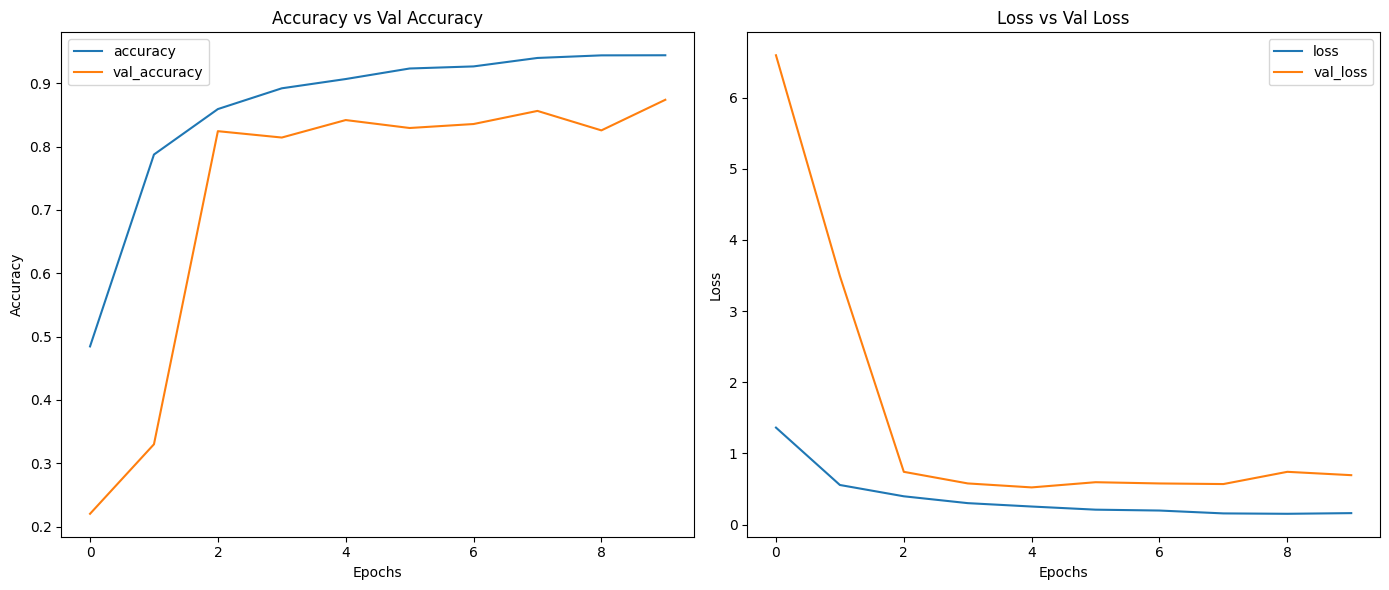

In [15]:

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(history.history['accuracy'], label='accuracy')
ax[0].plot(history.history['val_accuracy'], label='val_accuracy')
ax[0].set_title('Accuracy vs Val Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

ax[1].plot(history.history['loss'], label='loss')
ax[1].plot(history.history['val_loss'], label='val_loss')
ax[1].set_title('Loss vs Val Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()